In [52]:
import pandas as pd
from pathlib import Path

# Build path safely
file_path = Path("../data/groceries.csv")

df = pd.read_csv(file_path)

df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [53]:
# Create unique transaction ID
df['Transaction'] = df['Member_number'].astype(str) + "_" + df['Date']

# Group items per transaction
basket = df.groupby('Transaction')['itemDescription'].apply(list)

# Convert to list
transactions = basket.tolist()

# Check
print(transactions[:5])

[['sausage', 'whole milk', 'semi-finished bread', 'yogurt'], ['whole milk', 'pastry', 'salty snack'], ['canned beer', 'misc. beverages'], ['sausage', 'hygiene articles'], ['soda', 'pickled vegetables']]


In [54]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

basket_df = pd.DataFrame(te_array, columns=te.columns_)

basket_df.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [55]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(basket_df, min_support=0.003, use_colnames=True)

frequent_itemsets.head()

,support,itemsets
0,0.004010,(Instant food products)
1,0.021386,(UHT-milk)
2,0.008087,(baking powder)
3,0.033950,(beef)
4,0.021787,(berries)


In [56]:
rules.to_csv("../outputs/rules.csv", index=False)

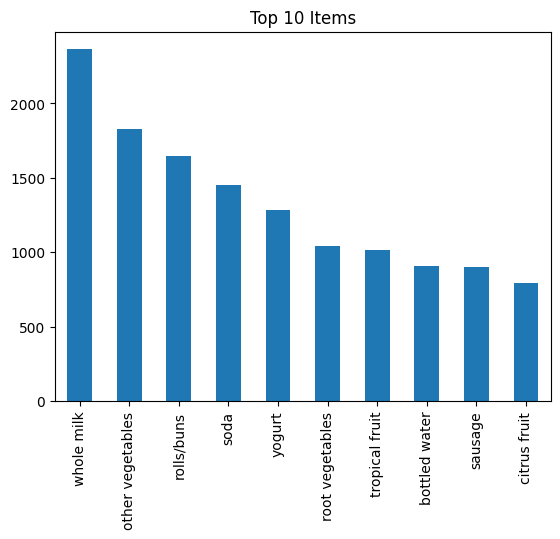

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top items
item_counts = basket_df.sum().sort_values(ascending=False).head(10)

item_counts.plot(kind='bar')
plt.title("Top 10 Items")
plt.show()

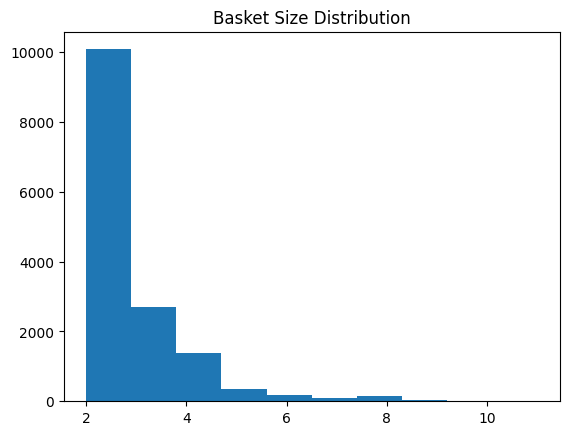

In [58]:
# Basket size
basket_sizes = [len(t) for t in transactions]

plt.hist(basket_sizes)
plt.title("Basket Size Distribution")
plt.show()

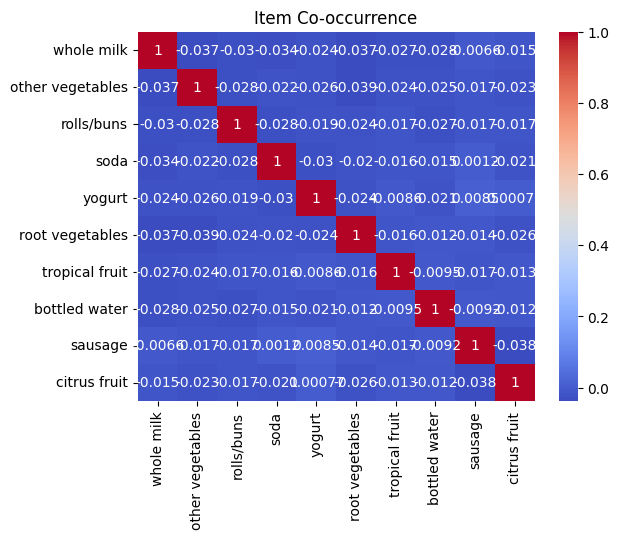

In [59]:
# Heatmap
top_items = item_counts.index
subset = basket_df[top_items]

sns.heatmap(subset.corr(), annot=True, cmap="coolwarm")
plt.title("Item Co-occurrence")
plt.show()

In [60]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.05)

# Remove strict lift filter (TEMPORARILY)
rules = rules[rules['lift'] > 0.5]

print("Number of rules:", len(rules))
rules.head()

Number of rules: 131


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(beef),(whole milk),0.033950,0.157923,0.004678,0.137795,0.872548,1.0,-0.000683,0.976656,-0.131343,0.024991,-0.023902,0.083709
1,(bottled beer),(other vegetables),0.045312,0.122101,0.004678,0.103245,0.845568,1.0,-0.000854,0.978973,-0.160585,0.028747,-0.021479,0.070780
2,(bottled beer),(rolls/buns),0.045312,0.110005,0.004010,0.088496,0.804471,1.0,-0.000975,0.976403,-0.202926,0.026502,-0.024168,0.062474
3,(bottled beer),(sausage),0.045312,0.060349,0.003342,0.073746,1.222000,1.0,0.000607,1.014464,0.190292,0.032658,0.014258,0.064559
4,(sausage),(bottled beer),0.060349,0.045312,0.003342,0.055371,1.222000,1.0,0.000607,1.010649,0.193337,0.032658,0.010537,0.064559


## Insights

- Whole milk is the most frequent item.
- Strong association between yogurt and whole milk.
- Customers usually buy 2–5 items per transaction.
- FP-Growth is faster than Apriori.

In [61]:
print(len(rules))
rules.head()

# ADD THIS LINE ↓↓↓
rules.to_csv("../outputs/rules.csv", index=False)

131
